# Two maps, and the ground truth for both

A multi-echo gradient echo is acquired for the sake of the two **maps** that can be fitted from
it: $T_2^*$ from how the magnitude decays across the train, and $\Delta B_0$ from how the phase
turns. [`01_build.ipynb`](01_build.ipynb) checked the grids, the fly-back area, the dwell quantum
and the echo times — none of which can say whether a fitted map comes back at the right number.

This notebook can, because **both maps have an oracle in the phantom**:

| fitted | oracle |
|---|---|
| $T_2^*$, from $\log\lvert S\rvert$ against `te_s` | $1/(1/T_2 + 1/T_2')$, voxelwise, from the phantom's own maps |
| $\Delta B_0$, from $\arg S$ against `te_s` | `phantom.field_hz()`, the map the simulation actually ran against |

`subject05.npz` carries **`T2dash_map`** as well as `T2_map`, which is what makes the first row
possible and is why this example uses the phantom [`../phantom.py`](../phantom.py) already
prepares rather than one of its own.

**All three of `01`'s files go through one reconstruction** — ESPIRiT coil maps, then SENSE, with
POCS first for the partial echo — so what differs between the pictures below is the *readout* and
nothing else.

1. **k-space to images.** The coil maps, the partial-Fourier fill, and the coil combination.
2. **What eight echoes look like**, in magnitude and in phase, before anything is fitted.
3. **The two maps, for all three sequences**, against both oracles.
4. **What partial echo costs**, and what POCS gets back.

In [1]:
import os
import sys

# Set before torch is imported, which is where it reads them.  Only the CPU path uses them, and
# MRzero's inner loop is dense complex linear algebra that will take every core it is offered.
SIM_THREADS = 4
for _var in ('OMP_NUM_THREADS', 'MKL_NUM_THREADS', 'RAYON_NUM_THREADS',
             'OPENBLAS_NUM_THREADS', 'NUMEXPR_NUM_THREADS'):
    os.environ[_var] = str(SIM_THREADS)

# cupy compiles its kernels at run time and needs a CUDA root to do it, which it looks for in
# ``CUDA_PATH``.  A conda environment keeps one under ``Library/`` on Windows and at the prefix
# itself elsewhere, and cupy does not look there on its own.  Only filled in when it is unset,
# and only *used* if it turns out to work -- see ``RECON_DEVICE`` below.
_CUDA_ROOT = os.path.join(sys.prefix, 'Library') if os.name == 'nt' else sys.prefix
os.environ.setdefault('CUDA_PATH', _CUDA_ROOT)
os.environ['PATH'] = os.path.join(_CUDA_ROOT, 'bin') + os.pathsep + os.environ.get('PATH', '')

import time
from pathlib import Path

import matplotlib.pyplot as plt
import MRzeroCore as mr0
import numpy as np
import sigpy as sp
import sigpy.mri as smri
import torch

sys.path.insert(0, str(Path('..').resolve()))
import phantom as ph            # noqa: E402 -- the shared BrainWeb preparation, one directory up

torch.set_num_threads(SIM_THREADS)
plt.rcParams['figure.dpi'] = 40          # keeps the committed notebook a readable size

def _sim_device():
    """``'cuda'`` when torch has a device it can actually allocate on, else ``'cpu'``.

    ``torch.cuda.is_available()`` alone is not the question: it reports the *driver*, and it comes
    back true on a machine whose devices have all been hidden by ``CUDA_VISIBLE_DEVICES``, where
    ``device_count()`` is then zero and the first allocation raises.  Probed with the smallest
    tensor that would fail, for the same reason ``_recon_device`` probes rather than asks.
    """
    try:
        if torch.cuda.is_available() and torch.cuda.device_count() > 0:
            torch.zeros(1, device='cuda')
            return 'cuda'
    except Exception:                                           # noqa: BLE001 -- any failure
        pass                                                    # means the CPU, and nothing else
    return 'cpu'


#: Where the simulation runs.  MRzero is a torch computation over every voxel and every
#: configuration state, so it moves to a GPU wholesale -- and that is where nearly all of this
#: notebook's time goes.  Everything below is written against ``DEVICE`` rather than against
#: either answer, so the CPU path is the same notebook and not a second one.
DEVICE = _sim_device()


def _recon_device():
    """sigpy's device: the GPU only when cupy can actually compile a kernel on it.

    ``torch.cuda.is_available()`` does not answer this.  The two stacks find CUDA independently,
    and cupy is the one that needs a toolkit to compile against rather than a driver to talk to --
    so a machine can run the simulation on its GPU and still have no working cupy.  Probed with
    the smallest transform that would fail, because the alternative is a traceback thirty cells
    later.
    """
    if DEVICE == 'cuda':
        try:
            import cupy
            cupy.fft.fft2(cupy.zeros((8, 8), cupy.complex64))
            return sp.Device(0)
        except Exception:                                       # noqa: BLE001 -- any failure
            pass                                                # means the CPU, and nothing else
    return sp.Device(-1)


#: Where the reconstruction runs.  ``sp.Device(-1)`` is the CPU, and sigpy takes it as an argument.
RECON_DEVICE = _recon_device()

#: Slices in the slab, and the one property of it this example changes.  A phantom one voxel thick
#: reads a slice-select gradient as complete dephasing and returns exactly zero signal, so two is
#: the minimum that has anything to excite -- and this is the first example here that fits a *map*
#: voxelwise, so the excited slab has to be one tissue in z or "which slice is the oracle?" has no
#: answer.  Both slices are therefore the phantom's slice 64, the one every other 2D example
#: images.  Nothing in plane is changed: same maps, same field, same coil ring.
NZ, N_COILS, Z_CENTER = 2, 8, 64

#: Per coil, per k-space sample.  The fits below are a *precision* statement, so there has to be
#: something to be imprecise about.
NOISE_SNR = 400

SEQ_DIR = Path('seq')
FILES = ('megre_mono', 'megre_bipolar', 'megre_mono_pf075')

print(f'simulating on {DEVICE}, reconstructing on '
      f'{"gpu" if RECON_DEVICE.id >= 0 else "cpu"}'
      + (f' ({torch.cuda.get_device_name(0)})' if DEVICE == 'cuda' else ''))
print('three acquisitions of 128 lines x 8 echoes, then one ESPIRiT calibration and 24 SENSE')
print('reconstructions.  Every step below prints what it cost.')

d:\MIniconda\envs\NUM\Lib\site-packages\sigpy\config.py:27: UserWarning: Importing cupy.cuda.cudnn failed. For more details, see the error stack below:
DLL load failed while importing cudnn: The specified module could not be found.
  warnings.warn(


simulating on cuda, reconstructing on gpu (NVIDIA GeForce RTX 5070 Laptop GPU)
three acquisitions of 128 lines x 8 echoes, then one ESPIRiT calibration and 24 SENSE
reconstructions.  Every step below prints what it cost.


## 0. What the files say about themselves

`01` wrote `echoes`, `polarity`, the echo **samples**, the echo **polarities** and the `te_s`
array into every file's `[DEFINITIONS]`. So this notebook reads the echo times *out of the file*
rather than rebuilding the module — the same discipline `gre_epi_2d/02` applies by parsing the
written `.seq` with MRzero. If a reconstruction can only work by re-deriving the sequence that
produced the data, the file is not self-describing and a scanner could not have written it.

In [2]:
def definitions(path):
    """The ``[DEFINITIONS]`` block of a pulseq file, as floats, lists of floats and strings."""
    out, inside = {}, False
    for raw in Path(path).read_text().splitlines():
        line = raw.strip()
        if line.startswith('['):
            inside = line == '[DEFINITIONS]'
            continue
        if not inside or not line:
            continue
        key, _, rest = line.partition(' ')
        try:
            values = [float(p) for p in rest.split()]
        except ValueError:
            out[key] = rest.strip()
            continue
        out[key] = values[0] if len(values) == 1 else values
    return out


DEFS = {name: definitions(SEQ_DIR / f'{name}.seq') for name in FILES}
TE = {name: np.asarray(d['TE']) for name, d in DEFS.items()}

NX, NY = 128, 128
FOV_MM = DEFS['megre_mono']['FOV'][0] * 1e3
ECHOES = int(DEFS['megre_mono']['Echoes'])

print(f'{"file":20s} {"polarity":10s} {"BW":>7s} {"dTE":>9s} {"TE1":>8s} {"TE8":>8s} '
      f'{"spread":>9s} {"samples":>8s}')
for name, d in DEFS.items():
    te = TE[name]
    print(f'{name:20s} {d["Polarity"]:10s} {d["ReceiverBandwidth"]:6.1f} '
          f'{d["EchoSpacing"] * 1e6:8.1f}us {te[0] * 1e3:7.4f} {te[-1] * 1e3:7.4f} '
          f'{np.ptp(np.diff(te)) * 1e6:8.2f}us {int(d["NumSamples"]):8d}')

shared = {name: (d['FlipAngle'], d['TR'], d['SliceThickness'], tuple(d['FOV']))
          for name, d in DEFS.items()}
assert len(set(shared.values())) == 1, shared
print()
print(f'flip, TR, slice and FOV are identical in all three files: '
      f'{shared["megre_mono"][0]:.0f} deg, {shared["megre_mono"][1] * 1e3:.0f} ms, '
      f'{shared["megre_mono"][2] * 1e3:.0f} mm')
print('so every comparison below is between *readouts*, not between contrasts.')

file                 polarity        BW       dTE      TE1      TE8    spread  samples
megre_mono           monopolar   500.8   2660.0us  3.2362 21.8562     0.00us      128
megre_bipolar        bipolar     488.3   2130.0us  3.2630 18.1570    32.00us      128
megre_mono_pf075     monopolar   500.8   2070.0us  2.7370 17.2270     0.00us       96

flip, TR, slice and FOV are identical in all three files: 15 deg, 40 ms, 3 mm
so every comparison below is between *readouts*, not between contrasts.


---
## 1. From k-space to images

Four steps, and each is a place where a multi-echo acquisition differs from a single-echo one.

**Undo the reversal, and read which echoes to undo out of the file.** `EchoPolarity` and
`EchoSamples` are in the `[DEFINITIONS]`, so nothing here guesses a parity — reversing by
`echo % 2` happens to be right for these three files and is wrong for a train with navigators in
front of it, and the wrong branch is not an error: it is a mirrored echo, which against a
symmetric phantom looks entirely correct.

**Coil maps once, from one echo.** A coil sensitivity is a property of the *coil*, not of the echo
or of the sequence, so ESPIRiT runs once on the first echo of the fully sampled monopolar file and
the same maps reconstruct every echo of every file. That is not economy — using one set of maps is
what makes the phase of echo *e* comparable with the phase of echo 0, which is the entire
$\Delta B_0$ measurement. Re-estimating per echo would fold the thing being measured into the
estimate.

**POCS before SENSE, for the partial echo.** `megre_mono_pf075` samples 96 of 128 $k_x$ points,
and the missing 32 are not zeros to be ignored — they are a quarter of k-space, and POCS puts them
back using the fact that a real object's phase varies slowly. §4 measures what that is worth.

**SENSE, not root-sum-of-squares.** RSS throws the phase away and half of this notebook is a phase
measurement. `sigpy`'s `SenseRecon` returns one complex image per echo, coil-combined optimally
and with the coil phase divided out by the maps.

In [3]:
def uniform_slab():
    """The shared slab, made uniform along z so that "which slice is the oracle" has an answer."""
    slab = ph.slab(matrix=NX, nz=NZ, z_center=Z_CENTER, n_coils=N_COILS)
    mid = NZ // 2
    for name in ('PD', 'T1', 'T2', 'T2dash', 'D', 'B0', 'B1', 'coil_sens'):
        m = getattr(slab, name, None)
        if m is not None:
            setattr(slab, name, torch.cat([m[..., mid:mid + 1]] * NZ, dim=-1).contiguous())
    built = slab.build()
    return built.cuda() if DEVICE == 'cuda' else built


def sampled_kx(name):
    """Which of the ``NX`` grid points the readout visits.  Partial echo omits the rest."""
    d = DEFS[name]
    start = NX // 2 - int(d['EchoSamples'][0])
    out = np.zeros(NX, bool)
    out[start:start + int(d['NumSamples'])] = True
    return out


def kspace(name, obj, *, noise_snr=NOISE_SNR, seed=0):
    """``(echo, coil, ky, kx)``: play a file, un-reverse its echoes, and grid what came back."""
    seq = SEQS[name]
    graph = mr0.compute_graph(seq, obj, max_state_count=64, min_state_mag=1e-4)
    # `.cpu()` because everything downstream -- the gridding, POCS, the fits -- is numpy, and one
    # transfer of 128 x 8 x 128 x 8 complex numbers is cheaper than any of them.
    signal = np.asarray(mr0.execute_graph(graph, seq, obj, print_progress=False).cpu())

    d = DEFS[name]
    echoes, taken = int(d['Echoes']), int(d['NumSamples'])
    rows = signal.reshape(-1, echoes, taken, signal.shape[-1])
    polarity = np.asarray(d['EchoPolarity'], int)
    samples = np.asarray(d['EchoSamples'], int)

    out = np.zeros((rows.shape[0], echoes, NX, rows.shape[3]), dtype=np.complex64)
    for echo in range(echoes):
        row = rows[:, echo] if polarity[echo] > 0 else rows[:, echo, ::-1]
        centre = samples[echo] if polarity[echo] > 0 else taken - 1 - samples[echo]
        start = NX // 2 - centre
        out[:, echo, start:start + taken] = row

    grid = np.transpose(out, (1, 3, 0, 2))
    if noise_snr:
        # Only where the receiver was open: a partial echo's missing kx is *unmeasured*, and
        # noise there would be data POCS then had to undo.
        rng = np.random.default_rng(seed)
        sigma = float(np.abs(grid).max()) / noise_snr
        noise = rng.standard_normal(grid.shape) + 1j * rng.standard_normal(grid.shape)
        grid = grid + (sigma / np.sqrt(2)) * noise * sampled_kx(name)[None, None, None, :]
    return grid


def ifft2c(k):
    return np.fft.fftshift(np.fft.ifft2(np.fft.ifftshift(k, axes=(-2, -1)), norm='ortho'),
                           axes=(-2, -1))


def fft2c(x):
    return np.fft.fftshift(np.fft.fft2(np.fft.ifftshift(x, axes=(-2, -1)), norm='ortho'),
                           axes=(-2, -1))


def pocs(ksp, sampled, *, iterations=12):
    """Fill the unsampled kx: phase from the symmetric centre, magnitude from the iterate.

    ``examples/se_epi_2d/02``'s implementation, unchanged -- a partial echo is a partial echo
    whether the train that produced it was echo-planar or Cartesian.
    """
    covered = np.flatnonzero(sampled)
    half = min(covered.max() - NX // 2, NX // 2 - covered.min())
    window = np.zeros(NX)
    window[NX // 2 - half:NX // 2 + half + 1] = np.hanning(2 * half + 1)
    phase = np.exp(1j * np.angle(ifft2c(ksp * window[None, :])))
    out = ksp.copy()
    for _ in range(iterations):
        out = fft2c(np.abs(ifft2c(out)) * phase)
        out[..., sampled] = ksp[..., sampled]
    return out

In [4]:
began = time.perf_counter()
SEQS = {name: mr0.Sequence.import_file(str(SEQ_DIR / f'{name}.seq')) for name in FILES}
if DEVICE == 'cuda':
    SEQS = {name: seq.cuda() for name, seq in SEQS.items()}
print(f'parsed three files in {time.perf_counter() - began:.1f} s')

slab = uniform_slab()
KSPACE = {}
for name in FILES:
    began = time.perf_counter()
    KSPACE[name] = kspace(name, slab, seed=FILES.index(name))
    print(f'{name:20s} {KSPACE[name].shape} (echo, coil, ky, kx) in '
          f'{time.perf_counter() - began:.0f} s')

# One set of coil maps for everything, from the first echo of the fully sampled file: the highest
# SNR data here, and the only one whose k-space centre is symmetric.
began = time.perf_counter()
MAPS = sp.to_device(smri.app.EspiritCalib(KSPACE['megre_mono'][0], device=RECON_DEVICE,
                                          show_pbar=False).run(), -1)
print(f'\nESPIRiT: {MAPS.shape} coil maps in {time.perf_counter() - began:.1f} s')


def sense(ksp_echo, *, lamda=1e-3, max_iter=30):
    """One complex image from one echo's ``(coil, ky, kx)``, against the shared coil maps."""
    return sp.to_device(smri.app.SenseRecon(ksp_echo, MAPS, lamda=lamda, max_iter=max_iter,
                                            device=RECON_DEVICE, show_pbar=False).run(), -1)


IMAGES, began = {}, time.perf_counter()
for name in FILES:
    ksp, partial = KSPACE[name], not sampled_kx(name).all()
    if partial:
        ksp = np.stack([pocs(ksp[echo], sampled_kx(name)) for echo in range(ECHOES)])
    IMAGES[name] = np.stack([sense(ksp[echo]) for echo in range(ECHOES)])
    print(f'{name:20s} {"POCS + SENSE" if partial else "SENSE":13s} -> {IMAGES[name].shape}')
print(f'{ECHOES * len(FILES)} reconstructions in {time.perf_counter() - began:.1f} s')

parsed three files in 17.2 s
megre_mono           (8, 8, 128, 128) (echo, coil, ky, kx) in 4 s
megre_bipolar        (8, 8, 128, 128) (echo, coil, ky, kx) in 3 s
megre_mono_pf075     (8, 8, 128, 128) (echo, coil, ky, kx) in 3 s

ESPIRiT: (8, 128, 128) coil maps in 2.4 s
megre_mono           SENSE         -> (8, 128, 128)
megre_bipolar        SENSE         -> (8, 128, 128)
megre_mono_pf075     POCS + SENSE  -> (8, 128, 128)
24 reconstructions in 2.6 s


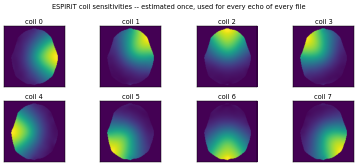

In [5]:
fig, axes = plt.subplots(2, N_COILS // 2, figsize=(10.0, 4.2))
for coil, ax in enumerate(axes.ravel()):
    ax.imshow(np.abs(MAPS[coil]), origin='lower', cmap='viridis')
    ax.set(title=f'coil {coil}', xticks=[], yticks=[])
fig.suptitle('ESPIRiT coil sensitivities -- estimated once, used for every echo of every file')
fig.tight_layout()

### The oracles, and putting them in the same frame

The phantom is **192 mm** across — 1.5 mm per voxel over 128 of them, read off its own affine —
and this protocol images **220 mm**. So the object fills 112 of the 128 pixels, and image pixel
*i* is not the phantom voxel with the same index: the two grids are 14 % apart in scale. Comparing
them directly leaves a smooth map looking like a scaled copy of itself and destroys a textured one
outright, and neither failure looks like a geometry error — the first reads as a calibration
problem and the second as noise.

`onto_image_grid` resamples the **oracle** onto the reconstruction's pixel grid, by **nearest
neighbour**: the oracle has to stay a set of values the phantom actually contains, and
interpolating between white matter at 54 ms and CSF at 161 ms would invent a $T_2^*$ that no voxel
has and then score the fit against it. Only the comparison moves — the sequence, the files and the
simulation are untouched — and the cell below **checks** the alignment against the object's own
extent rather than assuming it.

In [6]:
MID = NZ // 2
_slices = ph.slices_of(NZ, Z_CENTER)
_vol = ph.volume(matrix=NX)

#: The phantom's own in-plane extent, read off its affine rather than assumed.
PHANTOM_FOV_MM = float(ph.slab(matrix=NX, nz=NZ, z_center=Z_CENTER, n_coils=0).affine[0, 0]) * NX


def onto_image_grid(volume_map):
    """Resample a phantom-indexed map onto the reconstruction's pixel grid, nearest neighbour."""
    data = np.asarray(volume_map, dtype=float)
    image_mm = (np.arange(NX) + 0.5) * (FOV_MM / NX) - FOV_MM / 2
    index = np.round((image_mm + PHANTOM_FOV_MM / 2) / (PHANTOM_FOV_MM / NX) - 0.5).astype(int)
    inside = (index >= 0) & (index < NX)
    taken = data[np.clip(index, 0, NX - 1)][:, np.clip(index, 0, NX - 1)]
    return np.where(inside[:, None] & inside[None, :], taken, np.nan)


T2_TRUE = onto_image_grid(ph.same_frame(_vol.T2.numpy()[..., _slices][:, :, MID]))
T2DASH_TRUE = onto_image_grid(ph.same_frame(_vol.T2dash.numpy()[..., _slices][:, :, MID]))
PD_TRUE = onto_image_grid(ph.same_frame(_vol.PD.numpy()[..., _slices][:, :, MID]))
with np.errstate(divide='ignore', invalid='ignore'):
    T2STAR_TRUE = 1.0 / (1.0 / T2_TRUE + 1.0 / T2DASH_TRUE)
FIELD_TRUE = onto_image_grid(
    ph.same_frame(ph.field_hz(matrix=NX, nz=NZ, z_center=Z_CENTER)[:, :, MID]))
BRAIN = np.nan_to_num(PD_TRUE) > 0.15

# The alignment, checked rather than trusted, and checked against the alternative: how much of the
# object the oracle's support covers, with the resampling and without.  A Dice overlap rather than
# an extent, because an extent read off a noise threshold moves with the noise.
first = np.abs(IMAGES['megre_mono'][0])
seen = first > 0.10 * float(first.max())
naive = ph.same_frame(_vol.PD.numpy()[..., _slices][:, :, MID]) > 0.15
dice = lambda a, b: 2 * np.sum(a & b) / (a.sum() + b.sum())      # noqa: E731

print(f'the phantom is {PHANTOM_FOV_MM:.0f} mm across and this protocol images {FOV_MM:.0f} mm,')
print(f'so the object fills {PHANTOM_FOV_MM / FOV_MM * NX:.0f} of {NX} pixels.')
print(f'the object overlaps the oracle {dice(seen, BRAIN):.4f} on the image grid, against '
      f'{dice(seen, naive):.4f} without the resampling')
assert dice(seen, BRAIN) > 0.95, 'the oracle and the image are not in the same frame'
print()
print(f'{BRAIN.sum()} brain voxels; true T2* '
      f'{(np.nanpercentile(T2STAR_TRUE[BRAIN], [5, 50, 95]) * 1e3).round(1)} ms '
      f'(5th, 50th, 95th),')
print(f'true field {np.percentile(FIELD_TRUE[BRAIN], [1, 50, 99]).round(1)} Hz '
      f'(1st, 50th, 99th)')

the phantom is 192 mm across and this protocol images 220 mm,
so the object fills 112 of 128 pixels.
the object overlaps the oracle 0.9833 on the image grid, against 0.8804 without the resampling

7135 brain voxels; true T2* [ 53.8  74.2 161.4] ms (5th, 50th, 95th),
true field [-10.7  -1.1  40.6] Hz (1st, 50th, 99th)


---
## 2. What eight echoes look like

Before any fitting. The magnitude decays with $T_2^*$ and the phase **winds**, and those two are
the two maps — everything after this is a straight line through one or the other.

Three things are worth looking for. The magnitude falls fastest where $T_2^*$ is shortest, which
is grey matter rather than CSF. The phase is **wrapped** by the last echoes even though the field
is only tens of hertz, because 45 Hz over 18.6 ms is more than half a turn — which is why the fit
unwraps along the echo axis. And the phase at echo 0 is not zero: it is whatever phase the coil
maps and the excitation left, and it cancels because every echo carries the same one, which is
why §1 estimated the maps once.

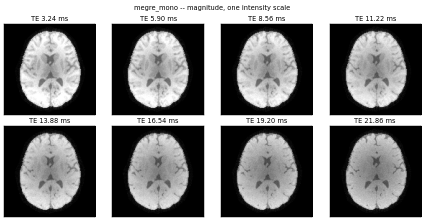

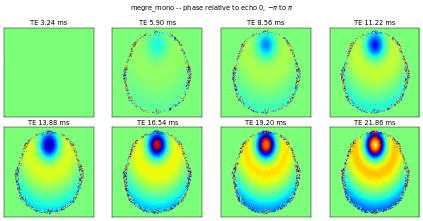

In [7]:
def show_echoes(name, *, kind='magnitude'):
    """All eight echoes of one file, on one intensity scale."""
    images = IMAGES[name]
    ceiling = float(np.abs(images[0])[BRAIN].max())*0.85
    fig, axes = plt.subplots(2, ECHOES // 2, figsize=(11.0, 5.6))
    for echo, ax in enumerate(axes.ravel()):
        if kind == 'magnitude':
            ax.imshow(np.abs(images[echo]), origin='lower',
                      cmap='gray', vmin=0, vmax=ceiling)
        else:
            relative = images[echo] * np.conj(images[0])
            ax.imshow(np.angle(relative), origin='lower',
                      cmap='jet', vmin=-np.pi, vmax=np.pi)
        ax.set(title=f'TE {TE[name][echo] * 1e3:.2f} ms', xticks=[], yticks=[])
    fig.suptitle(f'{name} -- '
                 + ('magnitude, one intensity scale' if kind == 'magnitude'
                    else 'phase relative to echo 0, $-\\pi$ to $\\pi$'))
    fig.tight_layout()


show_echoes('megre_mono', kind='magnitude')
show_echoes('megre_mono', kind='phase')

In [8]:
# The same thing as numbers, on the brightest tissue voxel: this is what the two fits are given.
row, col = np.unravel_index(np.argmax(np.where(BRAIN, np.abs(IMAGES['megre_mono'][0]), 0)),
                            (NX, NX))
signal = IMAGES['megre_mono'][:, row, col]
print(f'one voxel at ({row}, {col}): true T2* {T2STAR_TRUE[row, col] * 1e3:.1f} ms, '
      f'true field {FIELD_TRUE[row, col]:+.1f} Hz\n')
print(f'{"TE / ms":>9s} {"|S|":>10s} {"|S|/|S0|":>10s} {"arg(S/S0) / rad":>17s}')
for echo in range(ECHOES):
    relative = signal[echo] * np.conj(signal[0])
    print(f'{TE["megre_mono"][echo] * 1e3:8.3f} {np.abs(signal[echo]):10.4f} '
          f'{np.abs(signal[echo] / signal[0]):10.4f} {np.angle(relative):16.4f}')
print()
print('The magnitude column is the T2* fit and the phase column is the field fit, and both are')
print('straight lines against te_s -- which is the only reason two maps come out of one scan.')

one voxel at (16, 55): true T2* 54.1 ms, true field +11.5 Hz

  TE / ms        |S|   |S|/|S0|   arg(S/S0) / rad
   3.236    36.1687     1.0000           0.0000
   5.896    34.2104     0.9459          -0.2068
   8.556    31.3443     0.8666          -0.3769
  11.216    30.1577     0.8338          -0.6112
  13.876    29.2513     0.8087          -0.7276
  16.536    27.1617     0.7510          -0.9640
  19.196    26.4420     0.7311          -1.1284
  21.856    24.8428     0.6869          -1.3192

The magnitude column is the T2* fit and the phase column is the field fit, and both are
straight lines against te_s -- which is the only reason two maps come out of one scan.


---
## 3. The two maps, for all three sequences

Same reconstruction, same oracles, same fits — three readouts.

$T_2^*$ comes from a **weighted** straight line through $\log\lvert S\rvert$: the noise on
$\log\lvert S\rvert$ is $1/\lvert S\rvert$ times the noise on $\lvert S\rvert$, so an unweighted
fit lets the last and faintest echo pull the slope around.

$\Delta B_0$ comes from the phase of $S(e)$ relative to $S(0)$, unwrapped along the echo axis and
fitted against **`te_s`** — not against `TE₁ + n·echo_spacing_s`. `01` §5 computed what that
substitution costs from `te_s` alone: 0.036 % over eight echoes, and **0.75 % in every voxel** of
a two-point map. The bipolar column is where it would show, because that is the train whose echo
times alternate.

In [9]:
def fit_t2star(images, te_s, mask):
    """Weighted straight-line fit of log|S| against te_s, voxelwise."""
    magnitude = np.abs(images)
    y = np.log(np.maximum(magnitude, 1e-12))
    w = magnitude ** 2
    t = np.asarray(te_s)[:, None, None]
    with np.errstate(divide='ignore', invalid='ignore'):
        total = np.maximum(w.sum(0), 1e-30)
        centred = t - (w * t).sum(0) / total
        slope = ((w * centred * (y - (w * y).sum(0) / total)).sum(0)
                 / np.maximum((w * centred ** 2).sum(0), 1e-30))
        return np.where(mask & (slope < 0), -1.0 / slope, np.nan)


def fit_field(images, te_s, mask):
    """Hz, from the phase of ``S(e)`` relative to ``S(0)``, unwrapped along the echo axis."""
    relative = images * np.conj(images[0])
    phase = np.unwrap(np.angle(relative), axis=0)
    t = (np.asarray(te_s) - te_s[0])[:, None, None]
    w = np.abs(relative) ** 2
    with np.errstate(divide='ignore', invalid='ignore'):
        total = np.maximum(w.sum(0), 1e-30)
        centred = t - (w * t).sum(0) / total
        slope = ((w * centred * (phase - (w * phase).sum(0) / total)).sum(0)
                 / np.maximum((w * centred ** 2).sum(0), 1e-30))
    return np.where(mask, -slope / (2 * np.pi), np.nan)


T2STAR = {name: fit_t2star(IMAGES[name], TE[name], BRAIN) for name in FILES}
FIELD = {name: fit_field(IMAGES[name], TE[name], BRAIN) for name in FILES}

print(f'{"file":20s} {"T2* median":>11s} {"T2* IQR":>17s}   '
      f'{"dB0 slope":>10s} {"dB0 rms":>9s} {"dB0 corr":>9s}')
for name in FILES:
    ok = BRAIN & np.isfinite(T2STAR[name]) & np.isfinite(T2STAR_TRUE)
    err = (T2STAR[name][ok] - T2STAR_TRUE[ok]) / T2STAR_TRUE[ok] * 100
    okf = BRAIN & np.isfinite(FIELD[name])
    print(f'{name:20s} {np.median(err):+10.2f}% '
          f'[{np.percentile(err, 25):+6.2f},{np.percentile(err, 75):+6.2f}]%   '
          f'{np.polyfit(FIELD_TRUE[okf], FIELD[name][okf], 1)[0]:+10.4f} '
          f'{np.sqrt(np.mean((FIELD[name][okf] - FIELD_TRUE[okf]) ** 2)):8.3f}Hz '
          f'{np.corrcoef(FIELD[name][okf], FIELD_TRUE[okf])[0, 1]:+9.4f}')
print()
print('All three recover both maps.  The bipolar row is the one worth reading twice: its echoes')
print('alternate in polarity and its echo times alternate by two dwells about the period, and it')
print('lands on the same numbers as monopolar -- because the reconstruction reversed the echoes')
print('the file told it to reverse, and the fit used the te_s the file recorded.')

file                  T2* median           T2* IQR    dB0 slope   dB0 rms  dB0 corr
megre_mono                +0.27% [-10.29,+12.95]%      +1.0011    0.450Hz   +0.9992
megre_bipolar             -0.02% [-11.81,+15.23]%      +1.0009    0.491Hz   +0.9991
megre_mono_pf075          -0.16% [-14.21,+18.30]%      +1.0018    0.434Hz   +0.9993

All three recover both maps.  The bipolar row is the one worth reading twice: its echoes
alternate in polarity and its echo times alternate by two dwells about the period, and it
lands on the same numbers as monopolar -- because the reconstruction reversed the echoes
the file told it to reverse, and the fit used the te_s the file recorded.


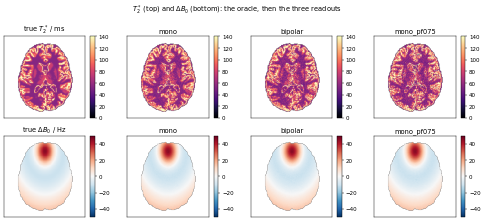

In [10]:
fig, axes = plt.subplots(2, len(FILES) + 1, figsize=(12.5, 5.6))
show = lambda ax, d, **kw: ax.imshow(np.where(BRAIN, d, np.nan), origin='lower', **kw)  # noqa: E731

plt.colorbar(show(axes[0, 0], T2STAR_TRUE * 1e3, cmap='magma', vmin=0, vmax=140),
             ax=axes[0, 0], fraction=0.046)
axes[0, 0].set(title='true $T_2^*$ / ms', xticks=[], yticks=[])
plt.colorbar(show(axes[1, 0], FIELD_TRUE, cmap='RdBu_r', vmin=-50, vmax=50),
             ax=axes[1, 0], fraction=0.046)
axes[1, 0].set(title='true $\\Delta B_0$ / Hz', xticks=[], yticks=[])

for column, name in enumerate(FILES, start=1):
    plt.colorbar(show(axes[0, column], T2STAR[name] * 1e3, cmap='magma', vmin=0, vmax=140),
                 ax=axes[0, column], fraction=0.046)
    axes[0, column].set(title=name.replace('megre_', ''), xticks=[], yticks=[])
    plt.colorbar(show(axes[1, column], FIELD[name], cmap='RdBu_r', vmin=-50, vmax=50),
                 ax=axes[1, column], fraction=0.046)
    axes[1, column].set(title=name.replace('megre_', ''), xticks=[], yticks=[])
fig.suptitle('$T_2^*$ (top) and $\\Delta B_0$ (bottom): the oracle, then the three readouts')
fig.tight_layout()

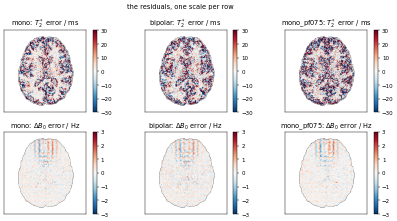

In [11]:
fig, axes = plt.subplots(2, len(FILES), figsize=(11.0, 5.6))
show = lambda ax, d, **kw: ax.imshow(np.where(BRAIN, d, np.nan), origin='lower', **kw)  # noqa: E731
for column, name in enumerate(FILES):
    plt.colorbar(show(axes[0, column], (T2STAR[name] - T2STAR_TRUE) * 1e3,
                      cmap='RdBu_r', vmin=-30, vmax=30), ax=axes[0, column], fraction=0.046)
    axes[0, column].set(title=f'{name.replace("megre_", "")}: $T_2^*$ error / ms',
                        xticks=[], yticks=[])
    plt.colorbar(show(axes[1, column], FIELD[name] - FIELD_TRUE,
                      cmap='RdBu_r', vmin=-3, vmax=3), ax=axes[1, column], fraction=0.046)
    axes[1, column].set(title=f'{name.replace("megre_", "")}: $\\Delta B_0$ error / Hz',
                        xticks=[], yticks=[])
fig.suptitle('the residuals, one scale per row')
fig.tight_layout()

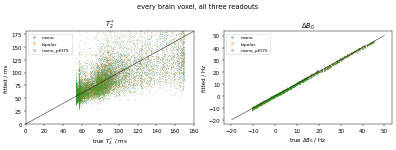

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(10.0, 3.8))
for name in FILES:
    ok = BRAIN & np.isfinite(T2STAR[name]) & np.isfinite(T2STAR_TRUE)
    axes[0].plot(T2STAR_TRUE[ok] * 1e3, T2STAR[name][ok] * 1e3, '.', ms=1.0, alpha=0.4,
                 label=name.replace('megre_', ''))
    okf = BRAIN & np.isfinite(FIELD[name])
    axes[1].plot(FIELD_TRUE[okf], FIELD[name][okf], '.', ms=1.0, alpha=0.4,
                 label=name.replace('megre_', ''))
axes[0].plot([0, 180], [0, 180], color='k', lw=0.8)
axes[0].set(xlabel='true $T_2^*$ / ms', ylabel='fitted / ms', xlim=(0, 180), ylim=(0, 180),
            title='$T_2^*$')
axes[1].plot([-20, 50], [-20, 50], color='k', lw=0.8)
axes[1].set(xlabel='true $\\Delta B_0$ / Hz', ylabel='fitted / Hz', title='$\\Delta B_0$')
for ax in axes:
    ax.legend(fontsize=8, markerscale=8)
fig.suptitle('every brain voxel, all three readouts')
fig.tight_layout()

The $T_2^*$ scatter is wider than the field map's, and the residual images say why: it is at
**tissue boundaries**. A 128-sample readout has a point spread about a voxel wide, so a boundary
voxel is a mixture of two tissues whose $T_2^*$ differ by a factor of three — and a mixture of two
exponentials is not an exponential. Its fitted time constant is pulled towards the slower one,
which is why that error is one-sided rather than scattered. The field map is smooth over the same
distance, so mixing neighbours costs it almost nothing.

---
## 4. What partial echo costs, and what POCS gets back

`megre_mono_pf075` samples 96 of 128 $k_x$ points. That buys a **shorter TE₁** — 2.74 ms against
3.24 — and a shorter echo spacing, 2070 µs against 2660, so the whole train fits into less time.
It costs the 32 $k_x$ points on the pre-echo side, which are a quarter of k-space.

POCS puts them back from the fact that a real object's phase varies slowly: take the phase from
the symmetric part of k-space, keep every measured sample, and iterate. Below, the same file
reconstructed both ways, with the full-echo file as the reference for what the object looks like
when nothing is missing.

In [13]:
mask_pf = sampled_kx('megre_mono_pf075')
print(f'{mask_pf.sum()} of {NX} kx points sampled; missing '
      f'{np.flatnonzero(~mask_pf).min()}..{np.flatnonzero(~mask_pf).max()} '
      f'(the pre-echo side)')

zero_filled = np.stack([sense(KSPACE['megre_mono_pf075'][echo]) for echo in range(ECHOES)])
with_pocs = IMAGES['megre_mono_pf075']
reference = IMAGES['megre_mono']

scale = lambda x: np.abs(x) / np.abs(x)[BRAIN].mean()           # noqa: E731
ref = scale(reference[0])
scored = {}
print()
print(f'{"":14s} {"|S0| nrmse vs full echo":>24s} {"T2* median":>12s} {"dB0 rms":>10s}')
for label, images in (('zero-filled', zero_filled), ('POCS', with_pocs)):
    t2s = fit_t2star(images, TE['megre_mono_pf075'], BRAIN)
    field = fit_field(images, TE['megre_mono_pf075'], BRAIN)
    ok = BRAIN & np.isfinite(t2s) & np.isfinite(T2STAR_TRUE)
    okf = BRAIN & np.isfinite(field)
    err = (t2s[ok] - T2STAR_TRUE[ok]) / T2STAR_TRUE[ok] * 100
    scored[label] = (
        float(np.sqrt(np.mean((scale(images[0])[BRAIN] - ref[BRAIN]) ** 2)) / ref[BRAIN].std()),
        float(np.median(err)),
        float(np.sqrt(np.mean((field[okf] - FIELD_TRUE[okf]) ** 2))),
    )
    print(f'{label:14s} {scored[label][0]:24.4f} {scored[label][1]:+11.2f}% '
          f'{scored[label][2]:9.3f}Hz')

zf, pc = scored['zero-filled'], scored['POCS']
print()
print(f'POCS buys the **image** and the **phase**: {100 * (1 - pc[0] / zf[0]):.0f} % off the error')
print(f'against the full-echo reference, and {100 * (1 - pc[2] / zf[2]):.0f} % off the field map,')
okm = BRAIN & np.isfinite(FIELD['megre_mono'])
full_rms = float(np.sqrt(np.mean((FIELD['megre_mono'][okm] - FIELD_TRUE[okm]) ** 2)))
print(f'which lands at {pc[2]:.3f} Hz against {full_rms:.3f} Hz for the full echo.')
print('It does almost nothing to T2*, and that is not a failure: a magnitude fit is dominated by')
print('the centre of k-space, which a partial echo still samples in full.  What the missing')
print('quarter costs is resolution and phase, and those are the two things POCS is for.')

96 of 128 kx points sampled; missing 0..31 (the pre-echo side)

                |S0| nrmse vs full echo   T2* median    dB0 rms
zero-filled                      0.3767       +0.20%     0.918Hz
POCS                             0.2533       -0.16%     0.434Hz

POCS buys the **image** and the **phase**: 33 % off the error
against the full-echo reference, and 53 % off the field map,
which lands at 0.434 Hz against 0.450 Hz for the full echo.
It does almost nothing to T2*, and that is not a failure: a magnitude fit is dominated by
the centre of k-space, which a partial echo still samples in full.  What the missing
quarter costs is resolution and phase, and those are the two things POCS is for.


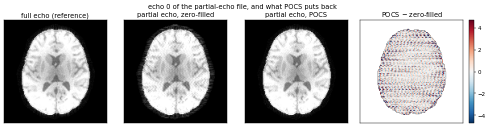

In [14]:
fig, axes = plt.subplots(1, 4, figsize=(12.5, 3.2))
ceiling = float(np.abs(reference[0])[BRAIN].max())*0.8
for ax, (title, image) in zip(axes[:3], (
    ('full echo (reference)', reference[0]),
    ('partial echo, zero-filled', zero_filled[0]),
    ('partial echo, POCS', with_pocs[0]),
)):
    ax.imshow(np.abs(image), origin='lower', cmap='gray',
              vmin=0, vmax=ceiling)
    ax.set(title=title, xticks=[], yticks=[])
difference = np.where(BRAIN, np.abs(with_pocs[0]) - np.abs(zero_filled[0]), np.nan)
limit = float(np.nanpercentile(np.abs(difference), 99))
plt.colorbar(axes[3].imshow(difference, origin='lower', cmap='RdBu_r', vmin=-limit, vmax=limit),
             ax=axes[3], fraction=0.046)
axes[3].set(title='POCS $-$ zero-filled', xticks=[], yticks=[])
fig.suptitle('echo 0 of the partial-echo file, and what POCS puts back')
fig.tight_layout()

---
## Summary

| claim | where | how it is known |
|---|---|---|
| the reverse lobe samples the forward grid | `01` §1 | 1.7 × 10⁻¹³ 1/m, against 0.2051 Δk on the lobe that is correct for a single line |
| the fly-back cancels the whole lobe | `01` §2 | −585.664336 1/m, and the three wrong answers built and plotted beside it |
| the barriers are not what keeps the lobes whole | `01` §3 | two, one and no barriers compile identically |
| the dwell lands on an RF-raster quantum | `01` §4 | 500 Hz/px asked for is 500.8 monopolar and 488.3 bipolar |
| `te_s` is not `echo_spacing_s` | `01` §5 | a two-point field map divided by the period instead is 0.75 % low everywhere, computed from `te_s` alone |
| the sequence measures $T_2^*$ and $\Delta B_0$ | `02` §3 | voxelwise against the phantom's own `T2dash_map` and `field_hz()` |
| and all three readouts agree | `02` §3 | monopolar, bipolar and partial echo, one reconstruction, two oracles |
| partial echo costs resolution, not $T_2^*$ | `02` §4 | POCS against zero-filling, against the full-echo image |

**And no class was defined in either notebook.** A multi-echo gradient echo is
`sc.modules.GRE2D(..., echoes=8, polarity='monopolar')`.